In [24]:
import pandas as pd, polars as pl, matplotlib.pyplot as plt
import os, subprocess

In [25]:
import datetime as dt

# Data reading

## load all 2024 months of taxi rides

# NOTE: due to limitations of my machine, i have been working onlu with 2024H1 data and anything on top of that was ending with catastrophic failure of my computer

In [26]:
# i am reusing loads used in exercises because they have nice way to prevent from 
#repeated redownload 
DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.mkdir(DATA_DIR)
# i was hopeful so i left all 12 parkiets to be loaded regardless of limitations of my RAM
for month in range(1, 13):
    if not os.path.exists(f"{DATA_DIR}/{month}.parquet"):
        subprocess.run(
            [
                "wget",
                f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-{month:02}.parquet",
                "-O",
                f"{DATA_DIR}/{month}.parquet",
            ]
        )


total_size = sum(
    os.path.getsize(f"{DATA_DIR}/{month}.parquet") for month in range(1, 13)
)  # bytes
total_size_mb = total_size // (1024 * 1024)
print(f"Total dataset size: {total_size_mb} MB")

Total dataset size: 660 MB


##    - also load taxi zone lookup data


In [27]:
#also i am borroing this one
if not os.path.exists(f"{DATA_DIR}/taxi_zone_lookup.csv"):
    subprocess.run(
        [
            "wget",
            "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
            "-O",
            f"{DATA_DIR}/taxi_zone_lookup.csv",
        ]
    )

## include only rides starting in 2024 and ending at most at 01.01.2025

In [28]:
dfs = []
for month in range(1, 7):
    df = pl.scan_parquet(f"{DATA_DIR}/{month}.parquet")
    df = df.with_columns(
        pl.col("tpep_pickup_datetime").dt.cast_time_unit("ms"),
        pl.col("tpep_dropoff_datetime").dt.cast_time_unit("ms"),
    )
    dfs.append(df)
df = pl.concat(dfs)
df.collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ms],datetime[ms],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-06-30 23:07:36,2024-06-30 23:18:35,null,2.51,null,null,255,148,0,21.09,0.0,0.5,0.0,0.0,1.0,25.09,null,null
2,2024-06-30 23:46:07,2024-07-01 00:11:53,null,7.55,null,null,68,74,0,33.96,0.0,0.5,0.0,0.0,1.0,37.96,null,null
2,2024-06-30 23:18:50,2024-06-30 23:35:09,null,4.25,null,null,41,100,0,21.01,0.0,0.5,0.0,0.0,1.0,25.01,null,null


In [29]:
df = (
    df.lazy().filter
    (
        (pl.col("tpep_pickup_datetime").dt.year() == 2024)
        & (pl.col("tpep_dropoff_datetime").dt.date() <= dt.date(2025,1,1))
    )
).collect()

## optimize data types, particularly for integers and categorical strings

In [30]:
#this crashes my computer, so i will just show the code that would be used to get the stats
#df.describe()

#so i am only taking the first 20 million rows to get the stats, which should be enough to get a good idea of the data
df.describe()

statistic,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
str,f64,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2.0332057e7,"""20332057""","""20332057""",1.8356072e7,2.0332057e7,1.8356072e7,"""18356072""",2.0332057e7,2.0332057e7,2.0332057e7,2.0332057e7,2.0332057e7,2.0332057e7,2.0332057e7,2.0332057e7,2.0332057e7,2.0332057e7,1.8356072e7,1.8356072e7
"""null_count""",0.0,"""0""","""0""",1.975985e6,0.0,1.975985e6,"""1975985""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.975985e6,1.975985e6
"""mean""",1.758161,"""2024-04-04 15:57:47.004000""","""2024-04-04 16:14:40.061000""",1.332897,4.704863,2.226115,null,164.797234,163.89703,1.102157,18.887131,1.408667,0.482437,3.270078,0.546815,0.970787,27.435929,2.249697,0.143439
"""std""",0.429628,null,null,0.830483,359.249938,10.538279,null,64.347085,69.540335,0.631572,77.285365,1.819552,0.121308,4.008414,2.214597,0.231557,78.551407,0.840454,0.493309
"""min""",1.0,"""2024-01-01 00:00:00""","""2024-01-01 00:02:42""",0.0,0.0,1.0,"""N""",1.0,1.0,0.0,-1285.4,-7.5,-0.5,-300.0,-117.26,-1.0,-1315.97,-2.5,-1.75
"""25%""",2.0,"""2024-02-21 21:43:30""","""2024-02-21 21:56:23""",1.0,1.02,1.0,null,132.0,113.0,1.0,9.3,0.0,0.5,0.0,0.0,1.0,15.64,2.5,0.0
"""50%""",2.0,"""2024-04-05 20:57:18""","""2024-04-05 21:12:02""",1.0,1.75,1.0,null,162.0,162.0,1.0,13.5,1.0,0.5,2.6,0.0,1.0,20.64,2.5,0.0
"""75%""",2.0,"""2024-05-18 02:57:52""","""2024-05-18 03:11:00""",1.0,3.3,1.0,null,234.0,234.0,1.0,21.9,2.5,0.5,4.16,0.0,1.0,29.85,2.5,0.0
"""max""",6.0,"""2024-07-01 00:05:23""","""2024-07-03 22:49:39""",9.0,312722.3,99.0,"""Y""",265.0,265.0,5.0,334076.32,65.99,35.84,999.99,1702.88,1.0,334145.3,2.52,1.75


In [31]:
df = df.lazy().with_columns(
    pl.col("VendorID").cast(pl.Int8),
    pl.col("tpep_pickup_datetime").cast(pl.Datetime),
    pl.col("tpep_dropoff_datetime").cast(pl.Datetime),
    pl.col("passenger_count").cast(pl.Int32),
    pl.col("trip_distance").cast(pl.Float32),
    pl.col("RatecodeID").cast(pl.Int8),
    pl.col("store_and_fwd_flag").cast(pl.Utf8),
    pl.col("PULocationID").cast(pl.Int16),
    pl.col("DOLocationID").cast(pl.Int16),
    pl.col("payment_type").cast(pl.Int8),
    pl.col("fare_amount").cast(pl.Float32),
    pl.col("extra").cast(pl.Float32),
    pl.col("mta_tax").cast(pl.Float32),
    pl.col("tip_amount").cast(pl.Float32),
    pl.col("tolls_amount").cast(pl.Float32),
    pl.col("improvement_surcharge").cast(pl.Float32),
    pl.col("total_amount").cast(pl.Float32),
    pl.col("congestion_surcharge").cast(pl.Float32),
    pl.col("Airport_fee").cast(pl.Float32)
).collect()

In [32]:
print(df.schema)

Schema({'VendorID': Int8, 'tpep_pickup_datetime': Datetime(time_unit='us', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='us', time_zone=None), 'passenger_count': Int32, 'trip_distance': Float32, 'RatecodeID': Int8, 'store_and_fwd_flag': String, 'PULocationID': Int16, 'DOLocationID': Int16, 'payment_type': Int8, 'fare_amount': Float32, 'extra': Float32, 'mta_tax': Float32, 'tip_amount': Float32, 'tolls_amount': Float32, 'improvement_surcharge': Float32, 'total_amount': Float32, 'congestion_surcharge': Float32, 'Airport_fee': Float32})


# Data cleaning and filtering

## all steps in one until it crashes and burns


In [33]:
df = (
    # lazify dataset otherwise my laptop would implode into black hole
    df.lazy().with_columns(
    # fill NULL values in `passengers_count` with 1    
    pl.col("passenger_count").fill_null(1)
    ).filter(
        # remove rides with zero passengers
        pl.col("passenger_count") > 0
    ).with_columns(
        (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")
         ).dt.total_minutes().alias("trip_duration")
    ).filter(
        # remove rides lasting over 2 hours
        pl.col("trip_duration") <=120
    ).with_columns(
        # if a ride has over 6 passengers, replace the value with 6
        pl.col("passenger_count").clip(upper_bound=6), #thats actually nice function
        # in all money-related columns, replace values with absolute value to fix negative amounts
        pl.col([
            'fare_amount',
            'extra',
            'mta_tax',
            'tip_amount',
            'tolls_amount',
            'improvement_surcharge',
            'total_amount',
            'congestion_surcharge',
            'Airport_fee']).abs()
    ).filter(
        # remove rides with over 1000 dollars in any money-related column
        # i tried ([list] <=1000).all() but it didn't work so using on-by-one instead
        pl.col('fare_amount') <= 1000,
        pl.col('extra') <= 1000,
        pl.col('mta_tax') <= 1000,
        pl.col('tip_amount') <= 1000,
        pl.col('tolls_amount') <= 1000,
        pl.col('improvement_surcharge') <= 1000,
        pl.col('total_amount') <= 1000,
        pl.col('congestion_surcharge') <= 1000,
        pl.col('Airport_fee') <= 1000
    ).filter(
        # remove rows with values of `RatecodeID` 
        # or `VendorID` missing or outside those defined in the data dictionary
        pl.col("VendorID").is_not_null(),
        pl.col("VendorID").is_in([1, 2,6,7]), #apparently these are viable
        pl.col('RatecodeID').is_not_null(),
        pl.col('RatecodeID').is_in([1, 2, 3, 4, 5, 6, 99])
    ).collect() # de-lazyfy dataframe
)


In [34]:
#checking with df.schema() cause df.describe shows weird data types for some reason 
print(df.schema)

Schema({'VendorID': Int8, 'tpep_pickup_datetime': Datetime(time_unit='us', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='us', time_zone=None), 'passenger_count': Int32, 'trip_distance': Float32, 'RatecodeID': Int8, 'store_and_fwd_flag': String, 'PULocationID': Int16, 'DOLocationID': Int16, 'payment_type': Int8, 'fare_amount': Float32, 'extra': Float32, 'mta_tax': Float32, 'tip_amount': Float32, 'tolls_amount': Float32, 'improvement_surcharge': Float32, 'total_amount': Float32, 'congestion_surcharge': Float32, 'Airport_fee': Float32, 'trip_duration': Int64})


# Data transformation

In [35]:
df = (
    df.lazy().with_columns(
        # combine payment type values for 
        # `"No charge"`, `"Dispute"`, `"Unknown"` and `"Voided trip"` into one type,
        # i hope thsi works 
        # i actually like the fact i can chain these 
        # i am mapping 0 - flex fare trip to others
        pl.col("payment_type").cast(pl.Utf8).replace({
            "0": "other",
            "1": "credit card",
            "2": "cash",
            "3": "other",
            "4": "other",
            "5": "other",
            "6": "other"
        }).alias("payment_type")
    ).collect()
)

In [36]:
# i am borrowing this from, exercise workbook
df_taxi_zones = pl.read_csv("data/taxi_zone_lookup.csv").lazy()

In [37]:
df = (
    df.lazy().with_columns(
        # combine payment type values for 
        # `"No charge"`, `"Dispute"`, `"Unknown"` and `"Voided trip"` into one type,
        # i hope thsi works 
        # i actually like the fact i can chain these 
        # i am mapping 0 - flex fare trip to others
        # i originally used utf8 for mapping function and then jumped to categorical
        pl.col("payment_type").cast(pl.Utf8).replace({
            "0": "other",
            "1": "credit card",
            "2": "cash",
            "3": "other",
            "4": "other",
            "5": "other",
            "6": "other"
        }).cast(pl.Categorical).alias("payment_type"),
        pl.col("store_and_fwd_flag").cast(pl.Categorical)
        # replace `PULocationID` and `DOLocationID` 
        # with borough names by 
        # joining taxi zone lookup and removing
        # unnecessary columns
        ).join(
            df_taxi_zones, left_on="PULocationID", right_on="LocationID"
        ).join(
            df_taxi_zones, left_on="DOLocationID", right_on="LocationID", suffix="_D"
        ).rename(
            {"Borough": "pickup_borough",
            "Borough_D": "dropoff_borough",
            "Airport_fee": "airport_fee"}
        ).drop(
            {"PULocationID", "DOLocationID"}
        # add boolean variable `is_airport_ride`, 
        # true if there is non-zero airport fee
        # add boolean variable `is_rush_hour`, 
        # rush hours are defined as 6:30–9:30 and 15:30-20:00 during weekdays
        ).with_columns(
            ((pl.col('airport_fee') > 0).alias('is_airport_ride')),
            ((pl.col('tpep_pickup_datetime').dt.weekday()< 6) #i hope this week doesnt start with sunday 
            & (
                (
                    (pl.col("tpep_pickup_datetime").dt.time() >= pl.time(6, 30))
                    & (pl.col("tpep_pickup_datetime").dt.time() <= pl.time(9, 30))
                ) | (
                    (pl.col("tpep_pickup_datetime").dt.time() >= pl.time(15, 30))
            & (pl.col("tpep_pickup_datetime").dt.time() <= pl.time(20, 0))
                )
            ) 
            ).alias("is_rush_hour")
        ).collect()
)

# Feature extraction

## dummy encoding

In [38]:
df = (
    df.to_dummies(
        columns=["payment_type", "pickup_borough", "dropoff_borough"]
    ).lazy().with_columns( 
        #open lazification sequence
        #make some dates
        pl.col('tpep_pickup_datetime').dt.date().alias('date')
    )
    .group_by("date")
    .agg(
        # - add integer variables for counting daily events:
        #      - total number of rides (target variable)
        #      - number of airport rides
        #      - number of rush hour rides
        pl.len().alias("total_rides"),
        pl.col("is_airport_ride").sum().alias("airport_rides"),
        pl.col("is_rush_hour").sum().alias("rush_hour_rides"),
        #    - add features aggregating daily rides information:
        #      - average fare amount
        #      - median distance
        #      - sum of total amounts
        #      - total amount paid by card, cash, and other
        #      - total congestion surcharge
        #      - total number of passengers)
        #since i have already made dummies/one-hots i will use them instead of ifs 
        #if its paid by card then that flag will be non-zero so that was handy
        (pl.col("total_amount") * pl.col("payment_type_credit card")).sum().alias("total_paid_by_card"),
        (pl.col("total_amount") * pl.col("payment_type_cash")).sum().alias("total_paid_by_cash"),
        (pl.col("total_amount") * pl.col("payment_type_other")).sum().alias("total_paid_by_other"),
        # some statistical wikitiki
        pl.col("fare_amount").mean().alias("average_fare_amount"),
        pl.col("trip_distance").median().alias("median_distance"),
        pl.col("total_amount").sum().alias("sum_total_amount")
    )
    .with_columns(
        # it felt wrong to have date attributes at the end so i moved them earlier i nthe execution order, before aggregsation
        # nevermind, actually it made sense cause otherwise i would need to have them in the aggregation 
        # and that would sound like additional effort my machine would not survive
        pl.col("date").dt.quarter().alias("quarter"),
        pl.col("date").dt.month().alias("month"),
        pl.col("date").dt.day().alias("day_of_month"),
        pl.col("date").dt.weekday().alias("day_of_week"),  
        (pl.col("date").dt.weekday() >= 6).alias("is_weekend")
    ).collect()
)
df

date,total_rides,airport_rides,rush_hour_rides,total_paid_by_card,total_paid_by_cash,total_paid_by_other,average_fare_amount,median_distance,sum_total_amount,quarter,month,day_of_month,day_of_week,is_weekend
date,u32,u32,u32,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,bool
2024-05-10,117618,9762,47369,2.9186e6,429103.1875,81869.710938,19.752596,1.62,3.4296e6,2,5,10,5,false
2024-04-04,114363,10381,45952,2.8347e6,431983.875,71002.875,19.731695,1.7,3.3377e6,2,4,4,4,false
2024-04-25,113152,9825,45449,2.887595e6,421643.84375,72370.34375,20.338404,1.7,3.3816e6,2,4,25,4,false
2024-03-20,106121,8360,44924,2.6018e6,364914.3125,63296.335938,19.149832,1.69,3.0301e6,1,3,20,3,false
2024-03-29,99827,8584,37603,2359280.5,400422.0625,76723.28125,19.202568,1.7,2.8365e6,1,3,29,5,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-02-28,102414,8396,43023,2.4910e6,335707.40625,56403.78125,18.900928,1.645,2.8832e6,1,2,28,3,false
2024-06-02,91579,11043,0,2.430578e6,353484.3125,75347.625,21.929125,1.9,2859462.5,2,6,2,7,true
2024-01-08,76969,7998,34807,1.8225e6,314640.0625,47359.074219,19.189875,1.71,2.1845e6,1,1,8,1,false


df.schema()

In [39]:
df.schema

Schema([('date', Date),
        ('total_rides', UInt32),
        ('airport_rides', UInt32),
        ('rush_hour_rides', UInt32),
        ('total_paid_by_card', Float32),
        ('total_paid_by_cash', Float32),
        ('total_paid_by_other', Float32),
        ('average_fare_amount', Float32),
        ('median_distance', Float32),
        ('sum_total_amount', Float32),
        ('quarter', Int8),
        ('month', Int8),
        ('day_of_month', Int8),
        ('day_of_week', Int8),
        ('is_weekend', Boolean)])

# Data Analysis

In [40]:
# print shape
print(df.shape)

(183, 15)


In [41]:
#show top rows
df.head(10)

date,total_rides,airport_rides,rush_hour_rides,total_paid_by_card,total_paid_by_cash,total_paid_by_other,average_fare_amount,median_distance,sum_total_amount,quarter,month,day_of_month,day_of_week,is_weekend
date,u32,u32,u32,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,bool
2024-05-10,117618,9762,47369,2.9186e6,429103.1875,81869.710938,19.752596,1.62,3.4296e6,2,5,10,5,false
2024-04-04,114363,10381,45952,2.8347e6,431983.875,71002.875,19.731695,1.7,3.3377e6,2,4,4,4,false
2024-04-25,113152,9825,45449,2.887595e6,421643.84375,72370.34375,20.338404,1.7,3.3816e6,2,4,25,4,false
2024-03-20,106121,8360,44924,2.6018e6,364914.3125,63296.335938,19.149832,1.69,3.0301e6,1,3,20,3,false
2024-03-29,99827,8584,37603,2359280.5,400422.0625,76723.28125,19.202568,1.7,2.8365e6,1,3,29,5,false
2024-04-16,101679,8718,42362,2.5187e6,381086.96875,62515.230469,19.754377,1.7,2.9624e6,2,4,16,2,false
2024-05-01,112215,9331,46604,2.787541e6,408245.4375,78023.882812,19.771141,1.7,3273828.5,2,5,1,3,false
2024-03-26,99090,8817,41648,2.4042e6,374413.03125,66067.65625,19.398891,1.71,2.844714e6,1,3,26,2,false
2024-03-14,118048,8917,48976,2.937889e6,425515.78125,70224.5,19.635929,1.72,3.433635e6,1,3,14,4,false


In [42]:
#describe statistics
df.describe()

statistic,date,total_rides,airport_rides,rush_hour_rides,total_paid_by_card,total_paid_by_cash,total_paid_by_other,average_fare_amount,median_distance,sum_total_amount,quarter,month,day_of_month,day_of_week,is_weekend
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""183""",183.0,183.0,183.0,183.0,183.0,183.0,183.0,183.0,183.0,183.0,183.0,183.0,183.0,183.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-04-01 00:00:00""",98990.857923,8567.398907,29771.284153,2.389069e6,366238.875,64645.445312,19.403107,1.712432,2.8200e6,1.508197,3.519126,15.595628,3.983607,0.284153
"""std""",null,14494.072614,1617.546171,19577.955679,379315.65625,49358.148438,12135.475586,1.102429,0.094143,429809.875,0.512148,1.728372,8.834273,2.012258,null
"""min""","""2024-01-01""",3.0,1.0,0.0,22.25,61.549999,0.0,16.676249,1.51,83.800003,1.0,1.0,1.0,1.0,0.0
"""25%""","""2024-02-16""",90902.0,7553.0,0.0,2188686.5,341757.03125,55960.539062,18.79154,1.66,2581948.5,1.0,2.0,8.0,2.0,null
"""50%""","""2024-04-01""",100460.0,8696.0,39652.0,2.4095e6,367526.84375,65782.382812,19.341881,1.7,2.844714e6,2.0,4.0,16.0,4.0,null
"""75%""","""2024-05-17""",109564.0,9762.0,44501.0,2611541.5,402303.125,73475.6875,20.214996,1.75,3074897.5,2.0,5.0,23.0,6.0,null
"""max""","""2024-07-01""",123574.0,12776.0,50831.0,3.215439e6,449946.96875,86760.21875,22.217703,2.09,3.7356e6,3.0,7.0,31.0,7.0,1.0


In [43]:
#print schema
print(df.schema)

Schema({'date': Date, 'total_rides': UInt32, 'airport_rides': UInt32, 'rush_hour_rides': UInt32, 'total_paid_by_card': Float32, 'total_paid_by_cash': Float32, 'total_paid_by_other': Float32, 'average_fare_amount': Float32, 'median_distance': Float32, 'sum_total_amount': Float32, 'quarter': Int8, 'month': Int8, 'day_of_month': Int8, 'day_of_week': Int8, 'is_weekend': Boolean})


## plottin

array([[<Axes: title={'center': 'total_rides'}>]], dtype=object)

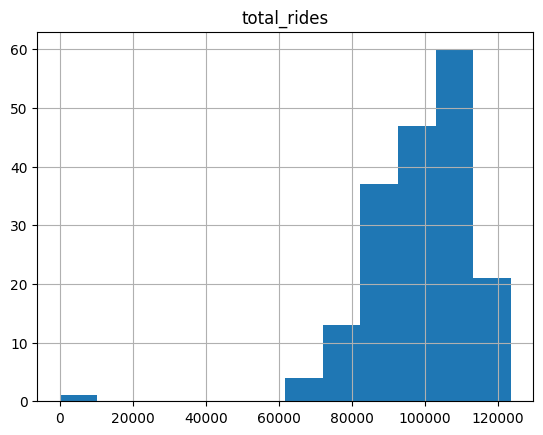

In [44]:
#histogram of values
# for daily total rides
df.to_pandas().hist("total_rides", bins=12)


<Axes: xlabel='date'>

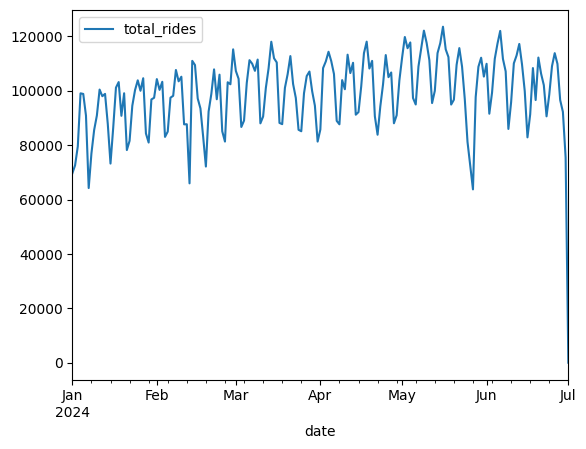

In [45]:
#line polot of total rides over date
dfx = df.to_pandas().sort_values("date") 
dfx.plot(x="date", y="total_rides", kind="line")